In [1]:
# Generelle moduler og funksjonsbeskrivelser brukt i forelesningen
from numpy import sin, cos, pi, exp
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = [8.00, 4.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.xmargin"] = 0.0

def pz_plot(sys):
    if isinstance(sys, sig._ltisys.StateSpaceContinuous):
        ax = plt.gca()
        ax.set_aspect('equal')
        ax.plot(np.real(sys.zeros), np.imag(sys.zeros), 'C0o', markersize=8, linewidth=0, markerfacecolor='none')
        ax.plot(np.real(sys.poles), np.imag(sys.poles),'C0x', markersize=8, linewidth=0, markerfacecolor='none')
        width = np.max(np.imag(sys.poles))
        ax.set_ylim([-width*1.1, width*1.1])
        ax.set_xlim([-width*1.2, width])
        ax.spines["left"].set_position(("data", 0))
        ax.spines["bottom"].set_position(("data", 0))
        # Hide the top and right spines.
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_title('Pole zero map')

    elif isinstance(sys, sig._ltisys.StateSpaceDiscrete):
        ax = plt.gca()
        ax.set_aspect('equal')
        ax.set_xlim([-1.2, 1.2])
        ax.set_ylim([-1.2, 1.2])
        ax.plot(np.real(sys.zeros), np.imag(sys.zeros), 'C0o', markersize=8, linewidth=0, markerfacecolor='none')
        ax.plot(np.real(sys.poles), np.imag(sys.poles),'C0x', markersize=8, linewidth=0, markerfacecolor='none')
        ax.plot(np.cos(np.linspace(0, 2*np.pi, 513)), np.sin(np.linspace(0, 2*np.pi, 513)),'k:')
        ax.set_title('Pole zero map')
        ax.set_xlabel(r'$\mathcal{Re}(z)$')
        ax.set_ylabel(r'$\mathcal{Im}(z)$')
    else:
        raise Exception("Input argument 'sys' not recognized as continuous or discrete LTI system")

%matplotlib ipympl

<img src="figurer/NTNU_logo_vertical.svg" align="left" width="30%">
<br clear="all" />
<br></br>

# Eksakt diskretisering i tidsdomenet

* **Emne AIS2102 - Dynamiske System**
* **Uke 8, 2025**
* **Underviser: Kai Erik Hoff**

# Case: Analyse av hybridsystem

<img src="figurer/hybridsystem.png" style="width: 80%" />

* Vi har lært hvordan vi diskretiserer regulatoren

* Hvordan kan vi kontrollere at reguleringssløyfen oppfører seg som ønsket?

# Diskretisering av prosess

<img src="figurer/prosess_disc.png" style="width: 80%" />

* Vi trenger å finne en *tidsdiskrét* ekvivalent $G_p(z)$ som representerer prosessen $G_p(s)$ der påbdrag $\bar{u}(t)$ er trappetrinnsformet
* Vir oss en fullstendig diskret representasjon av reguleringssløyfen

# Steg-invariant metode for diskretisering
* Andre navn: "Eksakt Diskretisering" eller "Zero Order Hold" diskretisering
* **Mål:**<br>
  > Gitt at $u(t)$ inn til systemet $G(s)$ holder en konstant verdi mellom sampletidspunkt $t \in k\cdot T_s$, finn et diskret system $G(z)$ der $y[k] = y(k\cdot T_s)$
* **Kan forenkles til:**
  > Finn et diskret system $G(z)$ hvor stegresponsen er en eksakt match med stegrespoinsen til systemet $G(s)$ i sampletidspunktene $t \in k\cdot T_s$

<img src="figurer/step_invariant.png" style="width: 80%" />

# Steg-invariant metode i tilsdandsrom
* Grunnprinsipp:
\begin{align*}
    \dot{\boldsymbol{x}}(t) &= \boldsymbol{A} \cdot \boldsymbol{x}(t) + \boldsymbol{B} \cdot \boldsymbol{u}(t) \\
  & \Downarrow \\
    \boldsymbol{x}[k] &= \int_0^{k\cdot T_s} \boldsymbol{A} \cdot \boldsymbol{x}(t) + \boldsymbol{B} \cdot \boldsymbol{\bar{u}}(t) dt
\end{align*}
    * Antar at $\bar{u}(t)$ er en *zero-order-hold* utgave av $u(t)$
[figur]

* **Mye** kronglete mellomregning gir:
\begin{align*}
    \boldsymbol{A_d} &= e^{\boldsymbol{A}\cdot T_s} \\
    \boldsymbol{B_d} &= \boldsymbol{A}^{-1}\cdot \left(e^{\boldsymbol{A}\cdot T_s} - \boldsymbol{I} \right) \\
    \boldsymbol{C_d} &= \boldsymbol{C}\\
    \boldsymbol{D_d} &= \boldsymbol{D}
\end{align*}
    * Merk at $e^{\boldsymbol{A}\cdot T_s}$ må utregnes ved hjelp av spesielle metoder (`scipy.linalg.expm` i python) som bruker taylorrekke-approksimasjon.

## Zero Order Hold diskretisering med Python

C:\Users\kaierih\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\signal\_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


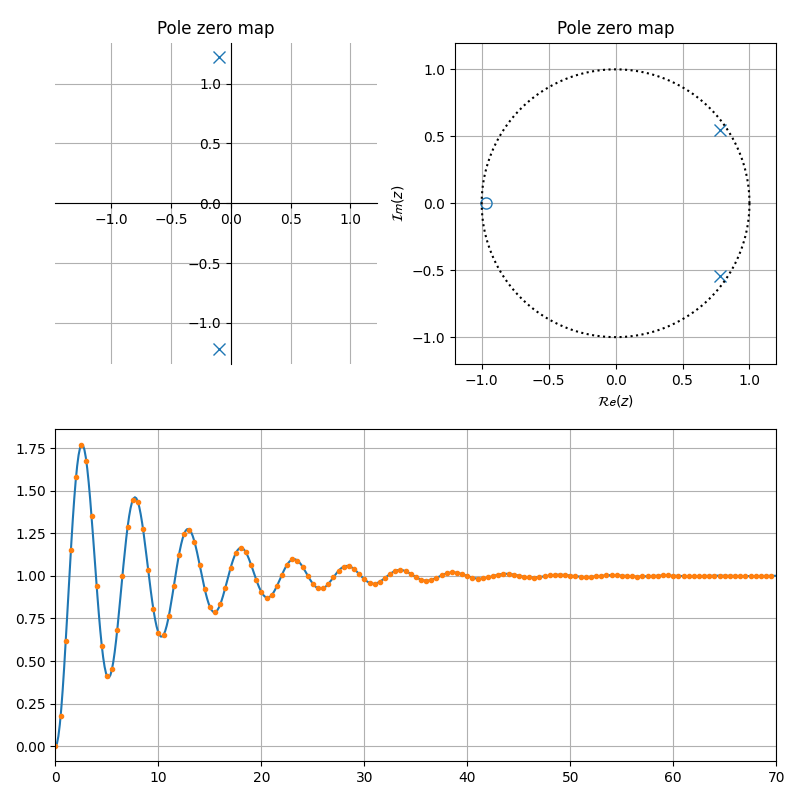

In [2]:
from scipy.linalg import expm

# Kontinuerlig system
A = np.array([[0, 1],
             [-1.5, -0.2]])
B = np.array([[0],
             [1.5]])
C = np.array([[1, 0]])
D = np.array([[0]])


# Diskretisering (kan også utføres med scipy.signal.cont2discrete)
Ts = 0.5
A_d = expm(A*Ts)
B_d = np.linalg.inv(A)@(expm(A*Ts) - np.eye(2))@B
C_d = C
D_d = D

sys = sig.StateSpace(A, B, C, D)
sys_ex1 = sig.StateSpace(A_d, B_d, C_d, D_d, dt=Ts)

plt.close(3); plt.figure(3, figsize=(8,8))
#fig, axes = plt.subplots(2,2, num=2, clear=True)
plt.subplot(2,2,1)
pz_plot(sys)
plt.subplot(2,2,2)
pz_plot(sys_ex1)
plt.subplot(2,2,(3,4))
t, yt = sys.step(N=500)
tk, (yk,) = sys_ex1.step(n=int(t[-1]/Ts))

plt.plot(t, yt)
plt.plot(tk, yk, '.')

# Python-eksempel

<img src="figurer/example_sys.png" style="width: 80%" />

* Diskretiser både regulator og prosess med $T_s = 0.05\text{s}$, og sammenlign stegresponser

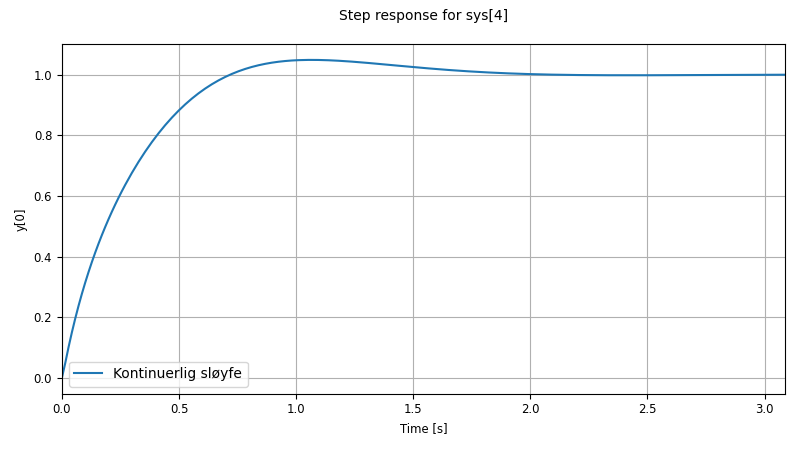

In [3]:
import control as ct

Ts = 0.05
plt.figure()

G_c = ct.TransferFunction([98, 797, 2369], [1, 476, 0])
G_p = ct.TransferFunction([20], [1, 10, 20])
feedback_cont = ct.feedback(G_c*G_p)
ct.step_response(feedback_cont).plot(label="Kontinuerlig sløyfe")

plt.legend()
plt.show()




#### Matlab-ekvivalent

```Octave

Ts = 0.05; % Sampletid

% Transferfunksjoner
s = tf('s');
Gp = 20/(s^2+10*s+20); % Prosess
zoh = tf(1, 1, 'InputDelay', Ts*0.5); % Forsinkelse ved D/A omforming
Gc = (98*s^2 + 979*s + 2369)/(s^2+476*s); % Regulator

G = Gp*Gc; % Open loop system

%figure
%margin(G)

%figure
step(feedback(G, 1))

Gc_d = c2d(Gc, Ts, 'tustin');
%tf(Gc_d)

Gp_d = c2d(Gp, Ts, 'zoh');

z = tf('z',Ts);
Gd = Gp_d*Gc_d;
hold on;
step(feedback(Gd,1))

```